# Trabajo Práctico número 2

Integrantes
- Gaspar Acevedo Zain (acevedo.zain.gaspar@gmail.com)

## Carga de utilities

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))

from utilities.image_quality import ImageQuality

## Pruebas

In [3]:
pathEnfocado = "../../Codigo/Clase3/enfocado.png"
pathDesenfocado = "../../Codigo/Clase3/desenfoque.png"

In [4]:
# def leer_imagen_y_obetener_quality_measure(imageQuality:ImageQuality , path:str, percentage:float = 1.0):
#     img = cv.imread(path)
#     imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)

#     result = imageQuality.imageQualityMeasure(image=imgRGB, roiPercentage=percentage)
#     return result

In [5]:
# def leer_imagen_y_obetener_tenengrad_measure(imageQuality:ImageQuality , path:str, percentage:float = 1.0):
#     img = cv.imread(path)
#     imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)

#     result = imageQuality.tenengradFocusMeasure(image=imgRGB, roiPercentage=percentage)
#     return result

In [6]:
imageQuality = ImageQuality()

In [7]:
# leer_imagen_y_obetener_quality_measure(imageQuality=imageQuality, path=pathEnfocado)

In [8]:
# leer_imagen_y_obetener_tenengrad_measure(imageQuality=imageQuality, path=pathEnfocado)

In [9]:
# leer_imagen_y_obetener_quality_measure(imageQuality=imageQuality, path=pathDesenfocado)

In [10]:
# leer_imagen_y_obetener_tenengrad_measure(imageQuality=imageQuality, path=pathDesenfocado)

0.03838534151034151

0.01581049967217114

In [11]:
# leer_imagen_y_obetener_quality_measure(imageQuality=imageQuality, path=pathEnfocado, percentage=0.1)

In [12]:
# leer_imagen_y_obetener_quality_measure(imageQuality=imageQuality, path=pathEnfocado, percentage=0.05)

In [13]:
# leer_imagen_y_obetener_quality_measure(imageQuality=imageQuality, path=pathDesenfocado, percentage=0.1)

In [14]:
# leer_imagen_y_obetener_quality_measure(imageQuality=imageQuality, path=pathDesenfocado, percentage=0.05)

### Prueba con video

In [15]:
def getQualityMeasureFromVideo(path:str, roiPercentage:float=1.0):
    captura_video = cv.VideoCapture(path)

    results = pd.DataFrame(columns=["Frame", "ImageSharpnessMeasure"])

    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
        return results
    else:
        frame_numero = 0
        while True:
            ret, frame = captura_video.read()
            if not ret:
                break

            iqm = imageQuality.imageQualityMeasure(image=frame, roiPercentage=roiPercentage)
            results.loc[len(results)] = [frame_numero, iqm]
            frame_numero = frame_numero + 1

    captura_video.release()
    return results

In [16]:
def getTenengradFocusMeasureFromVideo(path:str, roiPercentage:float=1.0):
    captura_video = cv.VideoCapture(path)

    results = pd.DataFrame(columns=["Frame", "ImageSharpnessMeasure"])

    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
        return results
    else:
        frame_numero = 0
        while True:
            ret, frame = captura_video.read()
            if not ret:
                break

            iqm = imageQuality.tenengradFocusMeasure(image=frame, roiPercentage=roiPercentage)
            results.loc[len(results)] = [frame_numero, iqm]
            frame_numero = frame_numero + 1

    captura_video.release()
    return results

In [17]:
def getBrennerGradientFocusMeasureFromVideo(path:str, roiPercentage:float=1.0):
    captura_video = cv.VideoCapture(path)

    results = pd.DataFrame(columns=["Frame", "ImageSharpnessMeasure"])

    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
        return results
    else:
        frame_numero = 0
        while True:
            ret, frame = captura_video.read()
            if not ret:
                break

            iqm = imageQuality.brennerGradientFocusMeasure(image=frame, roiPercentage=roiPercentage)
            results.loc[len(results)] = [frame_numero, iqm]
            frame_numero = frame_numero + 1

    captura_video.release()
    return results

In [26]:
def getVarianceOfLaplacianFocusMeasureFromVideo(path:str, roiPercentage:float=1.0):
    captura_video = cv.VideoCapture(path)

    results = pd.DataFrame(columns=["Frame", "ImageSharpnessMeasure"])

    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
        return results
    else:
        frame_numero = 0
        while True:
            ret, frame = captura_video.read()
            if not ret:
                break

            iqm = imageQuality.varianceOfLaplacianFocusMeasure(image=frame, roiPercentage=roiPercentage)
            results.loc[len(results)] = [frame_numero, iqm]
            frame_numero = frame_numero + 1

    captura_video.release()
    return results

In [18]:
video_path = '../../Material_TPs/TP2/focus_video.mov'

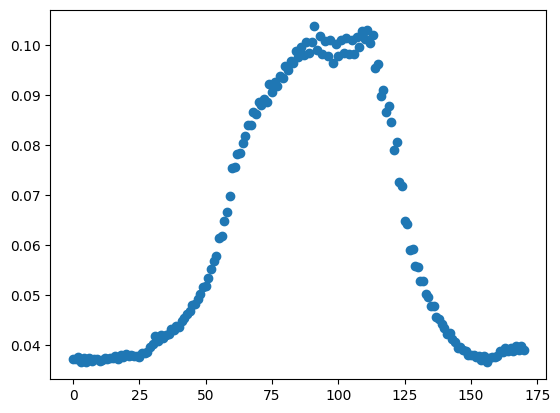

In [28]:
results = getQualityMeasureFromVideo(path=video_path, roiPercentage=1.0)
plt.scatter(results["Frame"], results["ImageSharpnessMeasure"])

In [ ]:
# results = getQualityMeasureFromVideo(path=video_path, roiPercentage=0.1)
# plt.scatter(results["Frame"], results["ImageSharpnessMeasure"])

In [21]:
# results = getQualityMeasureFromVideo(path=video_path, roiPercentage=0.05)
# plt.scatter(results["Frame"], results["ImageSharpnessMeasure"])

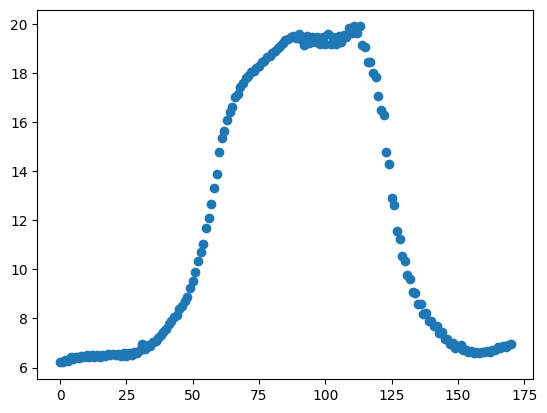

In [25]:
results = getTenengradFocusMeasureFromVideo(path=video_path, roiPercentage=1.0)
plt.scatter(results["Frame"], results["ImageSharpnessMeasure"])

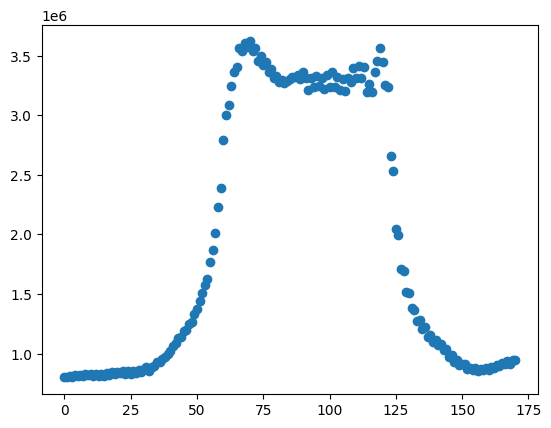

In [24]:
results = getBrennerGradientFocusMeasureFromVideo(path=video_path, roiPercentage=1.0)
plt.scatter(results["Frame"], results["ImageSharpnessMeasure"])

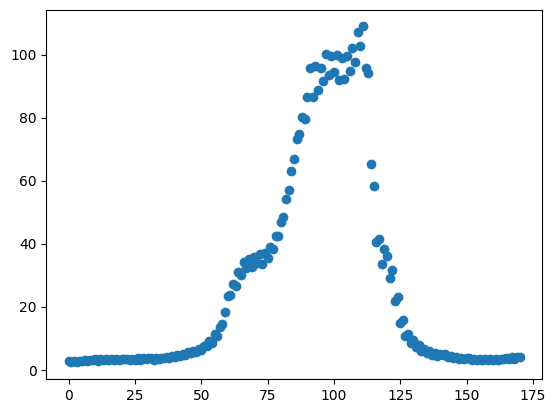

In [27]:
results = getVarianceOfLaplacianFocusMeasureFromVideo(path=video_path, roiPercentage=1.0)
plt.scatter(results["Frame"], results["ImageSharpnessMeasure"])